# Minimal example network module

In [35]:
from climada.util.constants import SYSTEM_DIR

PATH_SAVE = SYSTEM_DIR.joinpath('test_networks')

## Prepare data

In [ ]:
## Helper functions
import shapely
from pathlib import Path
import climada_petals.engine.networks.nw_utils as nwu
from climada_petals.engine.networks.nw_base import Network
from climada_petals.engine.networks.nw_preps import simplified_network, ordered_network
from climada_petals.engine.networks.nw_impacts import LINE_EXPOSURES
from osm_flex import download, extract

def make_shape_from_bonds(bonds:list | tuple):
    """
    Create a rectangular polygon shape from bounding coordinates.

    Parameters
    ----------
    bonds : list of float
        A list containing four float values representing the bounding box
        coordinates in the order [min_x, min_y, max_x, max_y].

    Returns
    -------
    shapely.geometry.Polygon
        A rectangular polygon defined by the given bounding box coordinates.
    """

    return shapely.geometry.box(bonds[0],bonds[1],bonds[2],bonds[3])

def crop_gdf_shape(gdf, shape):
    """
    Crop a GeoDataFrame to a specific shape.
    Args:
        gdf (geopandas.GeoDataFrame): The GeoDataFrame to be cropped.
        shape (shapely.geometry.Polygon): The shape to crop the GeoDataFrame to.
    Returns:
        geopandas.GeoDataFrame: The cropped GeoDataFrame.
    """
    return gdf[gdf.geometry.within(shape)]

def nw_prep(gdf, ci_type, reg_shape):
    """General wrapper function for CI data prep. Calls specific prep functions."""
    #crop to shape
    gdf = crop_gdf_shape(gdf, reg_shape)
    if ci_type in LINE_EXPOSURES:
        network = Network(edges=gdf)
    else:
        network = Network(nodes=gdf)
    network = simplified_network(network)
    network = ordered_network(network, {'ci_type':ci_type})
    return network

def road_prep_osm(reg_shape, path_ctr_dump):
    gdf_roads = osm_flex.extract.extract_cis(path_ctr_dump, "road")
    gdf_roads = gdf_roads[gdf_roads.geometry.type=='LineString']
    gdf_roads = gdf_roads[['osm_id','highway', 'geometry']]
    return nw_prep(gdf_roads, "road", reg_shape)

# General infra from OSM
def ci_prep_osm(ci_type, path_ctr_dump, reg_shape):
    gdf_osm = extract.extract_cis(path_ctr_dump, ci_type)
    gdf_osm['geometry'] = gdf_osm.geometry.apply(lambda geom: geom.centroid)
    gdf_osm = gdf_osm[['name', 'geometry']]
    return nw_prep(gdf_osm, ci_type, reg_shape)

def pop_prep(iso3, reg_shape, filename, up_fct=1, ppl_ctf=0):
    """Wrapper function to prepare people network data."""
    # Load and process people data
    gdf_people = nwu.load_resampled_raster(PATH_SAVE / filename, up_fct, extent=reg_shape.bounds)
    gdf_people['latitude'] = gdf_people.geometry.y
    gdf_people['longitude'] = gdf_people.geometry.x
    pop_thresh = nwu.get_pop_cutoff(gdf_people, ppl_ctf)
    gdf_people['value']=gdf_people['counts']
    gdf_people = gdf_people[gdf_people.value>=pop_thresh].reset_index(drop=True)
    return nw_prep(gdf_people, "people", reg_shape)

In [74]:
#define region
from climada.util import coordinates as u_coords
cntry = 'Sudan'
bonds = [33.1, 19.41666667, 33.45, 19.7]
iso3 = u_coords.country_to_iso(cntry)
#reg_shape = u_coords.get_admin1_info([countries])
reg_shape = make_shape_from_bonds(bonds)

extract points: 0it [00:00, ?it/s]
extract multipolygons: 0it [00:07, ?it/s]
topology: 100%|██████████| 735/735 [00:00<00:00, 5357.92it/s]


<Axes: >

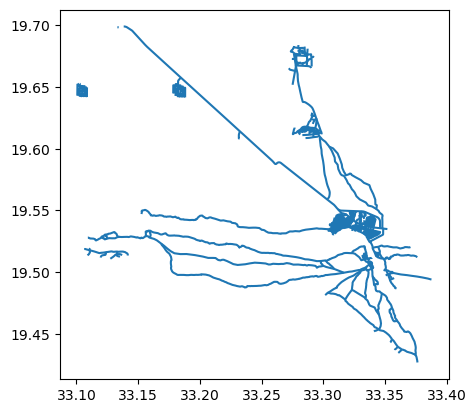

In [75]:
#load ci data using osm_flex
path_ctr_dump = download.get_country_geofabrik(iso3)

#load roads
road_network = road_prep_osm(reg_shape, path_ctr_dump=path_ctr_dump)
road_network.edges.plot()


extract multipolygons: 100%|██████████| 310/310 [00:14<00:00, 21.68it/s]
endpoints: 0it [00:00, ?it/s]
topology: 0it [00:00, ?it/s]


<Axes: >

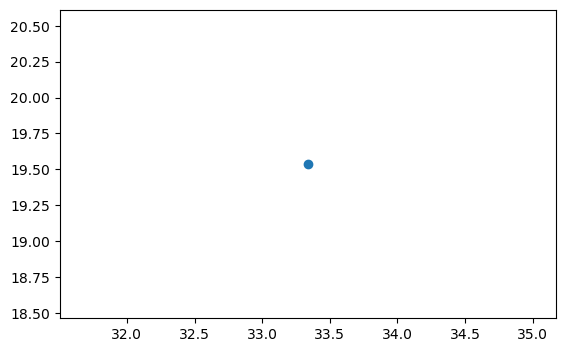

In [79]:
#load healthcare
healthcare_network = ci_prep_osm('healthcare', path_ctr_dump=path_ctr_dump, reg=reg_shape)
healthcare_network.nodes.plot()

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_utils.py:337: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cum = gdf_people.groupby(
endpoints: 0it [00:00, ?it/s]
/Users/lseverino/miniforge3/envs/nw_update/lib/python3.11/site-packages/geopandas/array.py:1755: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
topology: 0it [00:00, ?it/s]


<Axes: >

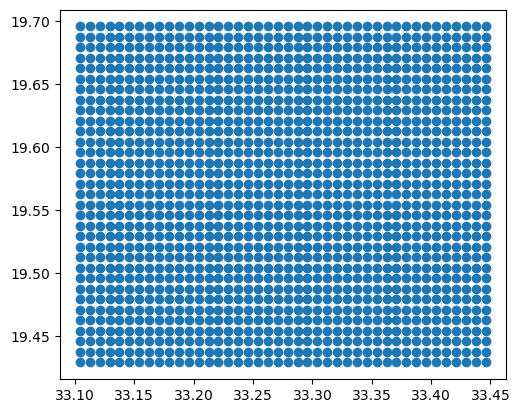

In [82]:
#load people
filename = f'{iso3.lower()}_ppp_2020_1km_Aggregated_UNadj.tif'
if not Path(PATH_SAVE / filename).is_file():
    nwu.get_worldpop_data(iso3, PATH_SAVE, res=1000)
people_network = pop_prep(iso3, reg_shape, filename, up_fct=1, ppl_ctf=0)
people_network.nodes.plot()

In [83]:
#combine
network_all = Network.from_nws([road_network, healthcare_network, people_network])

/Users/lseverino/miniforge3/envs/nw_update/lib/python3.11/site-packages/geopandas/array.py:1755: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_base.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges = pd.concat([edges, edge_gdf])
/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_base.py:98: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns whe

## Network and dependency set-up

In [ ]:
import pandas as pd
import numpy as np
#set up dependency table
def make_dependency_table():
    cols = ['Dep', 'source', 'target', 'n_links', 'access_cnstr', 'type_I',
       'type_II', 'thresh_func', 'thresh_dist', 'thresh_dur', 'conditions',
       'link_condition', 'via_link', 'bidir_link']
    return pd.DataFrame(columns=cols)

df_dependencies = make_dependency_table()

#add dependencies
df_dependencies = pd.DataFrame([
    #people to healthcare
    {
    'Dep': 'dependency_healthcare_people',
    'source': 'healthcare',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': True,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': 50000,
    'thresh_dur': 90,
    'conditions': None,
    'link_condition': 'distance',
    'via_link': 'road',
    'bidir_link': True
    },
    {
    'Dep': 'dependency_road_healthcare',
    'source': 'road',
    'target': 'healthcare',
    'n_links': 2,
    'access_cnstr': True,
    'type_I': 'functional',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': np.inf,
    'thresh_dur': None,
    'conditions': None,
    'link_condition': 'edgecond',
    'via_link': None,
    'bidir_link': True
    },
    {
    'Dep': 'dependency_road_people',
    'source': 'road',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': True,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': 1000,
    'thresh_dur': 60,
    'conditions': None,
    'link_condition': 'distance',
    'via_link': 'road',
    'bidir_link': True
    }])
df_dependencies


,Dep,source,target,n_links,access_cnstr,type_I,type_II,thresh_func,thresh_dist,thresh_dur,conditions,link_condition,via_link,bidir_link
0,dependency_healthcare_people,healthcare,people,1,True,enduser,logical,1,50000.0,90.0,None,distance,road,True
1,dependency_road_healthcare,road,healthcare,2,True,functional,logical,1,inf,NaN,None,edgecond,None,True
2,dependency_road_people,road,people,1,True,enduser,logical,1,1000.0,60.0,None,distance,road,True


In [101]:
from climada_petals.engine.networks.nw_calcs import NetworkCalcs

#create network calculator with dependency table
nw_calc_test = NetworkCalcs(network_all, dep_table=df_dependencies)

#add missing physical links
nw_calc_test.add_physical_links()

#initialize base state
nw_calc_test.initialize_base_state()

#setup dependencies
nw_calc_test.setup_dependencies()

#run cascade for base access state
nw_calc_test.cascade(criterion="distance", initial=True)

! adding distance
! adding distance
! adding distance
2025-11-27 16:02:58,415 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: -1
2025-11-27 16:02:58,440 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-11-27 16:02:58,442 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-11-27 16:02:58,598 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 2
2025-11-27 16:02:58,598 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-11-27 16:02:58,600 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-11-27 16:02:58,706 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 1
2025-11-27 16:02:58,707 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-11-27 16:02:58,708 - climada_petals.engi

In [103]:
nw_calc_test.network.edges.ci_type.unique()

array(['road', 'dependency_road_healthcare', 'dependency_road_people'],
      dtype=object)

ValueError: aspect must be finite and positive 

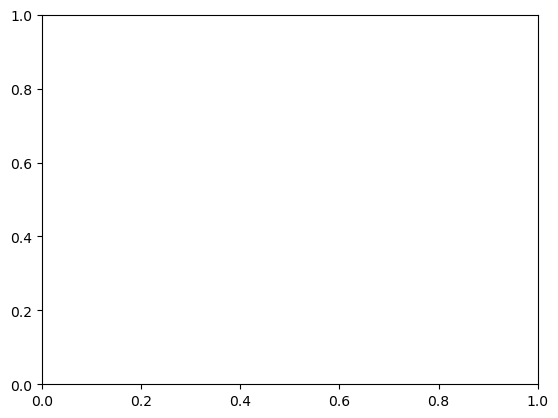

In [102]:
#check that everyhing looks ok
nw_calc_test.network.edges[nw_calc_test.network.edges.ci_type=="dependency_healthcare_people"].plot()

In [ ]:
nw_calc_test.network.nodes.plot(column="actual_supply_healthcare_people")#actual_supply_healthcare_people


## Network impact calculation

In [ ]:
#prepare impact functions
from src.impact_funcs import ImpFuncsThreshCI
impfid_dict = {
'road' : 1,
'healthcare' : 1,
'people' : 1
}
haz_type = "RF"
impf_thresh_set = ImpFuncsThreshCI(haz_type=haz_type, ci_types=ci_types)
for ci, impfid in impfid_dict.items():
    impf_thresh_set.setImpf(ci, impfid)

impf_thresh_set.impf_set.plot()

In [ ]:
#prepare hazard
from climada.hazard.base import Hazard


In [ ]:
from climada_petals.engine.networks.nw_impacts import exposure_from_edges, exposure_from_nodes
from climada_petals.engine.networks.nw_impacts import NetworkImpactCalc

#prepare exposures from base network
network_base = cp.deepcopy(nw_calc_test.network)
exp_ppl = exposure_from_nodes(network_base, ci_type="people", value_col="counts")
exp_hc = exposure_from_nodes(network_base, ci_type="healthcare", value=1)
exp_rd = exposure_from_edges(network_base, ci_type="road", res=500)
exp_list = [exp_ppl, exp_hc, exp_rd]


#select hazard, impf
haz = haz_all.select(event_id=[1])
impf_set = impf_thresh_set.impf_set
impf_thresh_set = impf_thresh_set

#create nw_impact_object
nw_impact_calc = NetworkImpactCalc(network=network_base, impf_set=impf_thresh_set,
                                   impf_thresh_set=impf_thresh_set, haz=haz, exp_list=exp_list)

#run impact calculation
network_disrupted, impact_dict = nw_impact_calc.disrupt_network()